In [1]:
# ==============================================================================
# CELL 1: PACKAGES AND PATH DEFINITIONS
# ==============================================================================
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix

# Define path matching your dataset folder structure
VAL_DIR = r"D:\AnacondaNotebooks\Notebooks\CocoaDiseaseClassification\dataset\val"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print(f"[INFO] TensorFlow Version: {tf.__version__}")
print("[INFO] Target validation directory configured.")

[INFO] TensorFlow Version: 2.21.0
[INFO] Target validation directory configured.


In [2]:
# ==============================================================================
# CELL 2: VALIDATION DATA STREAM INITIALIZATION
# ==============================================================================
# Initialize generator applying the exact same pre-processing as training
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Shuffle MUST be set to False to keep predictions aligned with true labels
val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Extract mappings for validation verification
class_labels = list(val_generator.class_indices.keys())
print(f"[INFO] Found classes mapped exactly as: {val_generator.class_indices}")

Found 1729 images belonging to 6 classes.
[INFO] Found classes mapped exactly as: {'Anthracnose': 0, 'CSSVD': 1, 'Healthy': 2, 'Monilia': 3, 'Phytophthora': 4, 'PodBorer': 5}


In [3]:
# ==============================================================================
# CELL 3: LOAD BEST SAVED MODEL WEIGHTS
# ==============================================================================
import os

MODEL_PATH = "max_efficiency_cocoa_model.keras"

if os.path.exists(MODEL_PATH):
    print(f"[INFO] Found saved model file: {MODEL_PATH}. Loading layers...")
    model = tf.keras.models.load_model(MODEL_PATH)
    print("[SUCCESS] Model compiled and loaded into active memory.")
else:
    print(f"[ERROR] '{MODEL_PATH}' not found in current directory!")
    print("[FIX] Ensure your working folder matches where Notebook 01 saved the file.")

[INFO] Found saved model file: max_efficiency_cocoa_model.keras. Loading layers...
[SUCCESS] Model compiled and loaded into active memory.


In [4]:
# ==============================================================================
# CELL 4: GENERATING METRIC PREDICTIONS MATRIX
# ==============================================================================
print("[INFO] Commencing prediction streaming over validation subset...")

# Predict probabilities across the batches
predictions = model.predict(val_generator, verbose=1)

# Extract indices with the highest confidence probability score
y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes

print("[SUCCESS] Inference complete. True values and predictions matched.")

[INFO] Commencing prediction streaming over validation subset...
55/55 ━━━━━━━━━━━━━━━━━━━━ 44s 749ms/step
[SUCCESS] Inference complete. True values and predictions matched.


In [5]:
# ==============================================================================
# CELL 5: PRINT COMPREHENSIVE PERFORMANCE PROFILE
# ==============================================================================
print("\n" + "="*20 + " FINAL CLASSIFICATION REPORT " + "="*20)
# Generate granular metrics to check precision, recall, and f1-scores
report = classification_report(y_true, y_pred, target_names=class_labels, digits=4)
print(report)
print("="*69)


==================== FINAL CLASSIFICATION REPORT ====================
              precision    recall  f1-score   support

 Anthracnose     0.6076    0.8421    0.7059       228
       CSSVD     0.6845    0.7975    0.7367       321
     Healthy     0.9137    0.7295    0.8113      1002
     Monilia     0.4516    0.4828    0.4667        29
Phytophthora     0.5187    0.6978    0.5951       139
    PodBorer     0.4762    1.0000    0.6452        10

    accuracy                         0.7519      1729
   macro avg     0.6087    0.7583    0.6601      1729
weighted avg     0.7888    0.7519    0.7594      1729



[SUCCESS] Heatmap chart successfully saved to disk as: 'final_confusion_matrix.png'


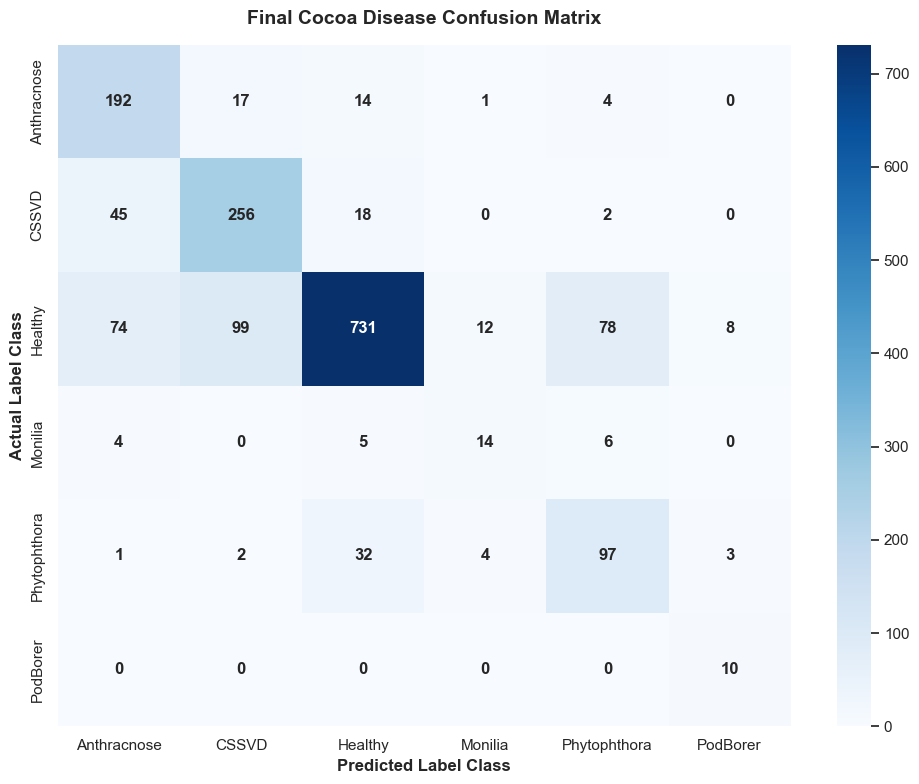

In [6]:
# ==============================================================================
# CELL 6: CONFUSION MATRIX GENERATION & IMAGE EXPORT
# ==============================================================================
# Compute confusion matrix array
cm = confusion_matrix(y_true, y_pred)

# Configure plot canvas sizing
plt.figure(figsize=(10, 8))
sns.set_theme(style="white")

# Render heatmap matrix
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_labels, 
    yticklabels=class_labels,
    cbar=True,
    annot_kws={"size": 12, "weight": "bold"}
)

plt.title('Final Cocoa Disease Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual Label Class', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label Class', fontsize=12, fontweight='bold')

# Clean layout presentation configurations
plt.tight_layout()

# Save image file to workspace folder for project review/documentation
output_img = "final_confusion_matrix.png"
plt.savefig(output_img, dpi=300)
print(f"[SUCCESS] Heatmap chart successfully saved to disk as: '{output_img}'")

plt.show()